<a href="https://colab.research.google.com/github/rasyadtanzilur/pengolahancitra/blob/main/JOBSHEET_05_MENGUKUR_KEMIRIPAN_CITRA_DAN_PENERAPANNYA_DALAM_PENGENALAN_POLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


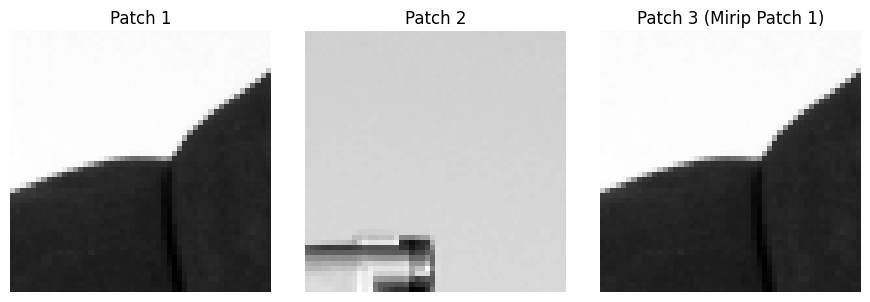

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

def main():
    # 1. Ambil citra grayscale dan konversi ke float [0, 1]
    image = img_as_float(data.camera())

    # 2. Ambil dua patch dari lokasi berbeda
    patch1 = image[100:150, 100:150]
    patch2 = image[100:150, 300:350]

    # 3. Buat patch3 sebagai patch1 dengan sedikit noise
    patch3 = np.clip(patch1 + 0.1, 0, 1)  # Hindari nilai > 1

    # 4. Flatten patch menjadi vektor 1D
    vec1 = patch1.flatten()
    vec2 = patch2.flatten()
    vec3 = patch3.flatten()

    # 5. Hitung jarak antara patch
    dist_l2_12 = distance.euclidean(vec1, vec2)
    dist_l2_13 = distance.euclidean(vec1, vec3)
    dist_l1_12 = distance.cityblock(vec1, vec2)
    dist_l1_13 = distance.cityblock(vec1, vec3)

    # 6. Tampilkan hasil perhitungan
    print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
    print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
    print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
    print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

    # 7. Tampilkan patch
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    titles = ['Patch 1', 'Patch 2', 'Patch 3 (Mirip Patch 1)']
    patches = [patch1, patch2, patch3]

    for ax, patch, title in zip(axes, patches, titles):
        ax.imshow(patch, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Same): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): 1.0000


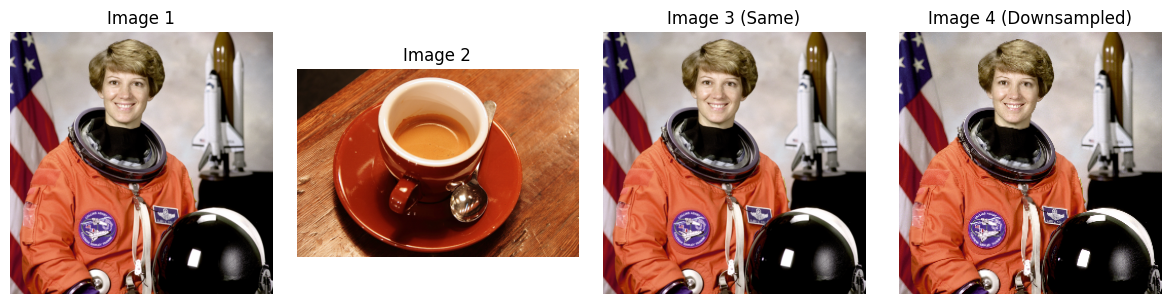

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined

def main():
    # 1. Muat citra
    try:
        image1 = data.astronaut()
        image2 = data.coffee()
        image3 = data.astronaut()
        image4 = image1[::2, ::2, :]  # Downsampled
    except Exception as e:
        print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
        image1 = np.random.rand(100, 100, 3)
        image2 = np.random.rand(100, 100, 3) * 0.5
        image3 = image1.copy()
        image4 = image1[::2, ::2, :]

    # 2. Hitung histogram
    hist1 = calculate_rgb_histogram(image1)
    hist2 = calculate_rgb_histogram(image2)
    hist3 = calculate_rgb_histogram(image3)
    hist4 = calculate_rgb_histogram(image4)

    # 3. Hitung Cosine Similarity
    sim_12 = 1 - distance.cosine(hist1, hist2)
    sim_13 = 1 - distance.cosine(hist1, hist3)
    sim_14 = 1 - distance.cosine(hist1, hist4)

    # 4. Tampilkan hasil
    print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
    print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Same): {sim_13:.4f}")
    print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): {sim_14:.4f}")

    # 5. Visualisasi
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    titles = ['Image 1', 'Image 2', 'Image 3 (Same)', 'Image 4 (Downsampled)']
    images = [image1, image2, image3, image4]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2959
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


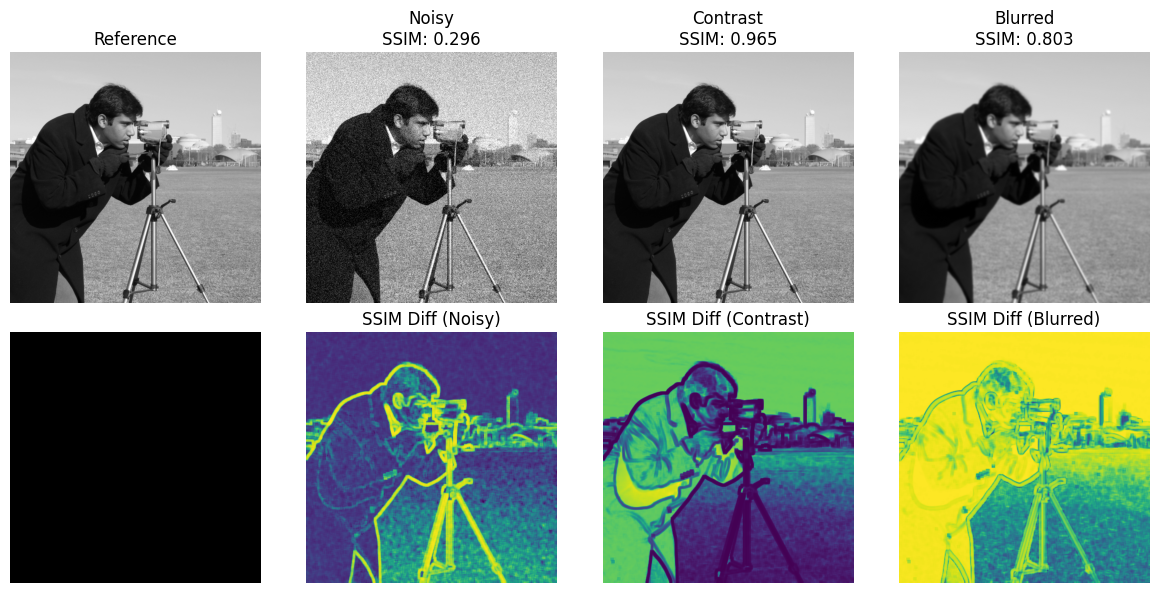

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

def main():
    # 1. Muat citra referensi
    image_ref = img_as_float(data.camera())

    # 2. Buat versi 'terdistorsi'
    image_same = image_ref.copy()
    image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
    image_contrast = np.clip(image_ref * 0.8, 0, 1)
    image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # grayscale

    # 3. Hitung SSIM (Structural Similarity Index)
    data_range = image_ref.max() - image_ref.min()
    ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
    ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
    ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
    ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

    # 4. Cetak hasil SSIM
    print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
    print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
    print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
    print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

    # 5. Visualisasi
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    ax = axes.ravel()

    # Baris 1: Citra
    ax[0].imshow(image_ref, cmap='gray')
    ax[0].set_title('Reference')
    ax[1].imshow(image_noisy, cmap='gray')
    ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
    ax[2].imshow(image_contrast, cmap='gray')
    ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
    ax[3].imshow(image_blurred, cmap='gray')
    ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')

    # Baris 2: Perbedaan SSIM
    ax[4].imshow(np.zeros_like(image_ref), cmap='gray')  # Placeholder kosong
    ax[4].set_title('')
    ax[5].imshow(diff_noisy, cmap='viridis')
    ax[5].set_title('SSIM Diff (Noisy)')
    ax[6].imshow(diff_contrast, cmap='viridis')
    ax[6].set_title('SSIM Diff (Contrast)')
    ax[7].imshow(diff_blurred, cmap='viridis')
    ax[7].set_title('SSIM Diff (Blurred)')

    # Bersihkan axis
    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


Praktikum 4. Penerapan Template Matching

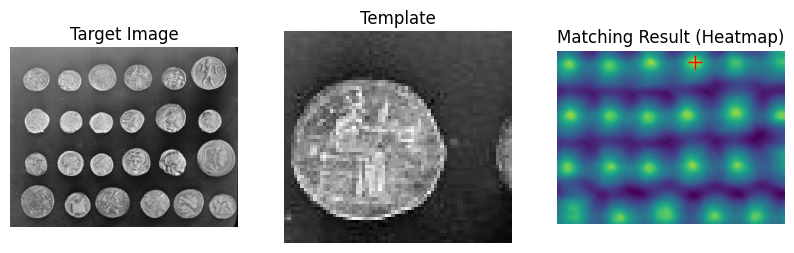

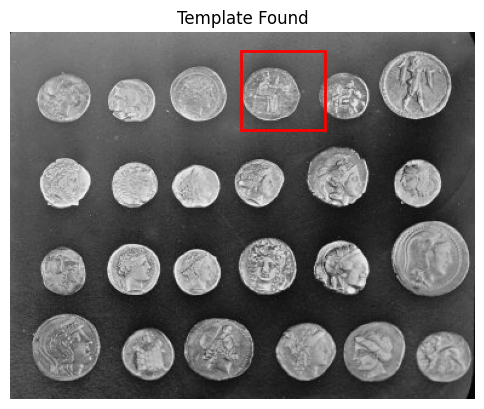

Template ditemukan di koordinat (x, y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan template
image = data.coins()
template = image[15:80, 190:260]  # Ambil salah satu koin sebagai template

# 2. Template matching (NCC)
result = match_template(image, template)

# 3. Temukan lokasi terbaik
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # ubah ke koordinat (x, y)

# 4. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].plot(x, y, 'r+', markersize=10)
ax[2].axis('off')

# Tampilkan kotak deteksi di citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')
h, w = template.shape
ax_main.add_patch(plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2))

plt.show()

# Cetak koordinat
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")


Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: coins (Distance: 0.288)
Rank 2: coffee (Distance: 0.359)
Rank 3: astronaut (Distance: 0.461)
Rank 4: camera (Distance: 0.602)


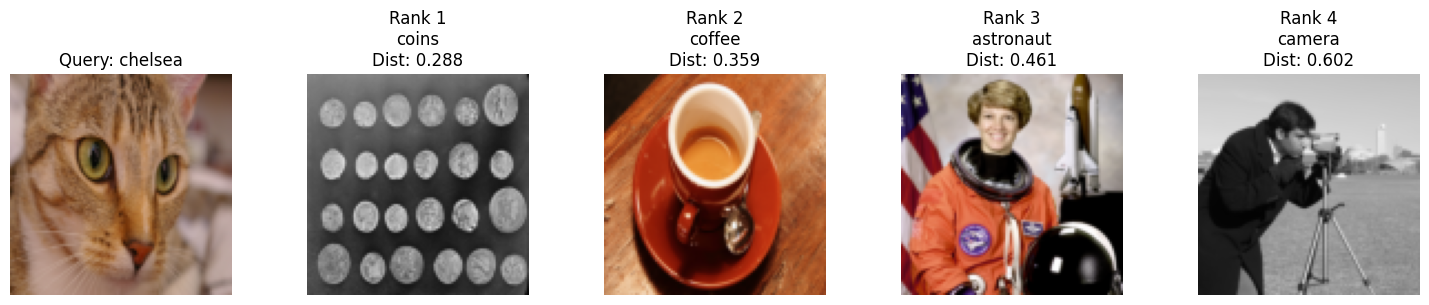

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)
    return hist_combined.astype(float) / hist_sum if hist_sum > 0 else hist_combined.astype(float)

image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

distances = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

sorted_indices = np.argsort(distances)

num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show, figsize=(15, 3))

# Query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for rank, idx in enumerate(sorted_indices[1:], start=1):  # Skip query sendiri
    ax = axes[rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


4. Template Matching Invariant: Cari tahu dari dokumentasi
skimage.feature.match_template atau sumber lain, apakah metode match_template
standar invariant terhadap rotasi atau perubahan skala? Jelaskan. (Petunjuk: Coba rotasi
atau ubah ukuran template pada Praktikum 4 dan lihat hasilnya).


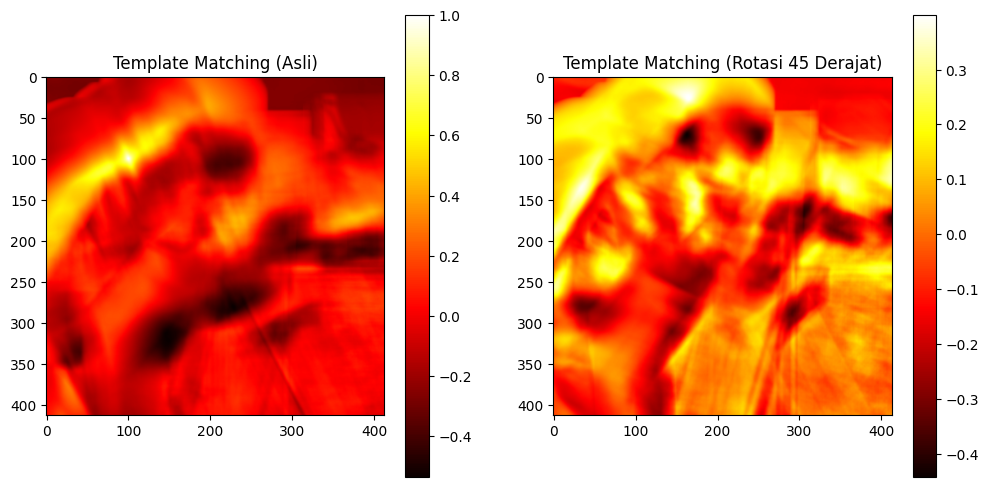

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, feature, transform, color

# Memuat citra contoh dan template
image = data.camera()  # Citra contoh
template = image[100:200, 100:200]  # Template dari bagian citra

# 1. Template matching pada citra asli
result = feature.match_template(image, template)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(result, cmap='hot')
plt.title('Template Matching (Asli)')
plt.colorbar()

# 2. Rotasi template dan template matching lagi
rotated_template = transform.rotate(template, angle=45)  # Memutar template 45 derajat
rotated_result = feature.match_template(image, rotated_template)

plt.subplot(1, 2, 2)
plt.imshow(rotated_result, cmap='hot')
plt.title('Template Matching (Rotasi 45 Derajat)')
plt.colorbar()

plt.show()



3. Fitur Berbeda untuk CBIR: Modifikasi Praktikum 5. Alih-alih menggunakan histogram
warna, coba gunakan fitur yang lebih sederhana seperti rata-rata warna (mean R, mean
G, mean B) sebagai vektor fitur 3 dimensi. Hitung kemiripan menggunakan Jarak
Euclidean (L_2) antara vektor fitur rata-rata warna ini. Bandingkan hasil retrievalnya dengan hasil yang menggunakan histogram. Manakah fitur yang lebih baik untuk
membedakan citra-citra dalam database kecil tersebut?

Results using Mean Color (Euclidean Distance):


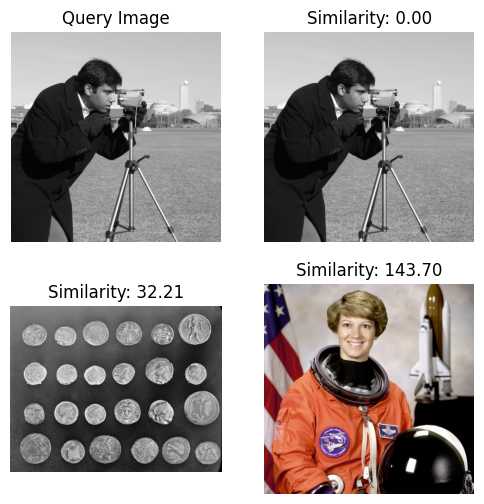

In [15]:
import numpy as np
import cv2
from skimage import data
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

# Fungsi untuk menghitung rata-rata warna (mean R, mean G, mean B)
def calculate_mean_color(image):
    mean_color = cv2.mean(image)[:3]  # mean_color = (mean_B, mean_G, mean_R)
    return mean_color

# Fungsi untuk membangun vektor fitur dari gambar
def build_feature_vector(image_list, method='mean_color'):
    feature_vectors = []
    image_paths = []

    for img in image_list:
        if method == 'mean_color':
            feature = calculate_mean_color(img)
        feature_vectors.append(feature)
        image_paths.append(img)

    return feature_vectors, image_paths

# Fungsi untuk menghitung kemiripan menggunakan Jarak Euclidean
def calculate_similarity(query_feature, feature_vectors, method='mean_color'):
    similarities = []
    for feature in feature_vectors:
        if method == 'mean_color':
            dist = euclidean(query_feature, feature)  # Menghitung jarak Euclidean
        similarities.append(dist)
    return similarities

# Fungsi untuk melakukan retrieval citra berdasarkan query
def retrieve_images(query_image, image_list, method='mean_color'):
    if method == 'mean_color':
        query_feature = calculate_mean_color(query_image)

    feature_vectors, image_paths = build_feature_vector(image_list, method)
    similarities = calculate_similarity(query_feature, feature_vectors, method)

    sorted_indices = np.argsort(similarities)  # Mengurutkan berdasarkan kemiripan terendah

    # Menampilkan gambar query
    plt.figure(figsize=(6, 6))
    plt.subplot(2, 2, 1)
    plt.imshow(query_image, cmap='gray')
    plt.title("Query Image")
    plt.axis('off')

    # Menampilkan gambar yang paling mirip
    for idx in range(min(3, len(sorted_indices))):
        plt.subplot(2, 2, idx + 2)
        plt.imshow(image_paths[sorted_indices[idx]], cmap='gray')
        plt.title(f"Similarity: {similarities[sorted_indices[idx]]:.2f}")
        plt.axis('off')

    plt.show()

# Menggunakan gambar contoh dari skimage
image_list = [data.camera(), data.coins(), data.astronaut()]  # Contoh gambar dari skimage
query_image = data.camera()  # Menggunakan gambar pertama sebagai citra query

# Retrieval menggunakan fitur rata-rata warna (mean R, mean G, mean B)
print("Results using Mean Color (Euclidean Distance):")
retrieve_images(query_image, image_list, method='mean_color')

